# Exjobb Cgroup Analysis

In [1]:
%pip install numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statistics

Note: you may need to restart the kernel to use updated packages.


In [2]:
SECONDS_TO_REMOVE = 5

def get_cgroup_recording(expid, runid, relpath):
    df = pd.read_csv(f'./traces/{expid}/{runid}/cg/{relpath}')

    if 'snapshot' in df.columns and not df.empty:
        trim_ns = SECONDS_TO_REMOVE * 1e9
        start_ts = df['snapshot'].iloc[0] + trim_ns
        end_ts = df['snapshot'].iloc[-1] - trim_ns

        if end_ts > start_ts:
            df = df[(df['snapshot'] >= start_ts) & (df['snapshot'] <= end_ts)]

    return df

def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/{expid}/{runid}/{runid}-trace.csv')
    return df

def get_experiment_info(expid):
    info = {}
    with open(f'./traces/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip()
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()
    
    return info



In [3]:
def udp_get_timestamp_of_first_and_last_packet(expid: str, runid: str):
    df = get_trace_dataset(expid, runid)
    first = df['timestamp1'].iloc[0]
    last = df['timestamp1'].iloc[-1]
    return (first, last)


def get_cpu_usec_from_run(expid: str, runid: str, filter=None, file_path="system/cpu.stat.csv"):
    """Calculates the used CPU time from a run"""
    df = get_cgroup_recording(expid, runid, file_path)

    if filter == "UDP":
        timestamp_packets = udp_get_timestamp_of_first_and_last_packet(expid, runid)
        # Convert seconds to nanoseconds for comparison with cpu.stat.csv timestamps
        ts_first_ns = timestamp_packets[0] * 1e9
        ts_second_ns = timestamp_packets[1] * 1e9
        # Filter rows to only include those between the first and second packet
        df = df[(df['snapshot'] >= ts_first_ns) & (df['snapshot'] <= ts_second_ns)]

    delta = df['usage_usec'].iloc[-1] - df['usage_usec'].iloc[0]
    print(f"EXPID: {expid}, RUNID: {runid}, DELTA={delta}")
    return delta

def get_mean_cpu_usec_from_exp(expid: str, filter=None, file_path="system/cpu.stat.csv"):
    usecs = []
    for i in range(1, 4):
        usecs.append(get_cpu_usec_from_run(expid, str(i), filter, file_path))
    mean = statistics.mean(usecs)
    arr = np.array(usecs, dtype=float); mean = arr.mean(); std = arr.std(ddof=1)
    print(f"Mean: {mean}, Std: {std}")
    
    return mean

def get_mean_usec_per_request(expid: str, filter=None, file_path="system/cpu.stat.csv"):
    return get_mean_cpu_usec_from_exp(expid, filter, file_path) / 3000


In [4]:
def get_mem_usage_from_run(expid: str, runid: str, file_path="system/meminfo.csv"):
    """Calculates mean used memory for a run from meminfo snapshots (MB)."""
    df = get_cgroup_recording(expid, runid, file_path)

    mem_used_kb = df['MemTotal'] - df['MemAvailable']
    mean_used_mb = mem_used_kb.mean() / 1024
    print(f"EXPID: {expid}, RUNID: {runid}, MEAN_MEM_USED_MB={mean_used_mb}")
    return mean_used_mb


def get_mean_mem_usage_from_exp(expid: str, filter=None, file_path="system/meminfo.csv"):
    mem_usage = []
    for i in range(1, 4):
        mem_usage.append(get_mem_usage_from_run(expid, str(i), file_path))
    mean = statistics.mean(mem_usage)
    arr = np.array(mem_usage, dtype=float); mean = arr.mean(); std = arr.std(ddof=1)
    print(f"Mean: {mean}, Std: {std}")
    
    return mean

In [5]:
def get_mean_pod_memory_usage_expid(expid, cgroup_dir_name):
    mem_usage = []
    for i in range(1, 4):
        df = get_cgroup_recording(expid, i, f"{cgroup_dir_name}/memory.current.csv")
        mean_usage = df["value"].mean() / (1024 * 1024)
        mem_usage.append(mean_usage)
    total_mean = statistics.mean(mem_usage)
    arr = np.array(mem_usage, dtype=float); mean = arr.mean(); std = arr.std(ddof=1)

    print(f"Mean mem_usage for EXPID: {expid}, {cgroup_dir_name} = {total_mean} MB \t Std: {std}")
    return total_mean

In [6]:
def plot_bar_cpu_per_req(experimentstocompare, axs, index, filter=None):
    for exp in experimentstocompare:
        val = get_mean_usec_per_request(exp['id'], filter)
        key = get_experiment_info(exp['id'])['Policy Direction']
        axs[index].set_title(get_experiment_info(exp['id'])['Dataplane'])
        axs[index].bar(key, val)

In [7]:
def plot_bar_cpu_per_req_istio(experimentstocompare, axs, index):
    for exp in experimentstocompare:
        sys_val = get_mean_usec_per_request(exp['id'])
        #istio_proxy_val = get_mean_usec_per_request(exp['id'], file_path="istio-proxy/cpu.stat.csv")
        label = f"Istio: {get_experiment_info(exp['id'])['Istio Installed'].capitalize()} - Policy: {get_experiment_info(exp['id'])['Istio Policy']}"
        axs[index].set_title(get_experiment_info(exp['id'])['Dataplane'])
        axs[index].barh(label, sys_val)
        axs[index].tick_params(axis='x', rotation=45, )

In [8]:
def plot_bar_mem_usage_istio(experimentstocompare, axs, index):
    for exp in experimentstocompare:
        sys_val = get_mean_mem_usage_from_exp(exp['id'])
        #istio_proxy_val = get_mean_usec_per_request(exp['id'], file_path="istio-proxy/cpu.stat.csv")
        label = f"Istio: {get_experiment_info(exp['id'])['Istio Installed'].capitalize()} - Policy: {get_experiment_info(exp['id'])['Istio Policy']}"
        axs[index].set_title(get_experiment_info(exp['id'])['Dataplane'])
        axs[index].barh(label, sys_val)
        axs[index].tick_params(axis='x', rotation=45, )

# UDP

EXPID: 40812, RUNID: 1, DELTA=136009000
EXPID: 40812, RUNID: 2, DELTA=140015000
EXPID: 40812, RUNID: 3, DELTA=138005000
Mean: 138009666.66666666, Std: 2003004.0772133572
EXPID: 40813, RUNID: 1, DELTA=137964000
EXPID: 40813, RUNID: 2, DELTA=136194000
EXPID: 40813, RUNID: 3, DELTA=136227000
Mean: 136795000.0, Std: 1012518.1479855065
EXPID: 40814, RUNID: 1, DELTA=135606000
EXPID: 40814, RUNID: 2, DELTA=135218000
EXPID: 40814, RUNID: 3, DELTA=137372000
Mean: 136065333.33333334, Std: 1148115.557482492
EXPID: 40815, RUNID: 1, DELTA=136453000
EXPID: 40815, RUNID: 2, DELTA=140242000
EXPID: 40815, RUNID: 3, DELTA=141177000
Mean: 139290666.66666666, Std: 2501563.577711615
EXPID: 40816, RUNID: 1, DELTA=133620000
EXPID: 40816, RUNID: 2, DELTA=135077000
EXPID: 40816, RUNID: 3, DELTA=133364000
Mean: 134020333.33333333, Std: 924008.8383415677
EXPID: 40817, RUNID: 1, DELTA=131047000
EXPID: 40817, RUNID: 2, DELTA=135224000
EXPID: 40817, RUNID: 3, DELTA=131840000
Mean: 132703666.66666667, Std: 2218394.0

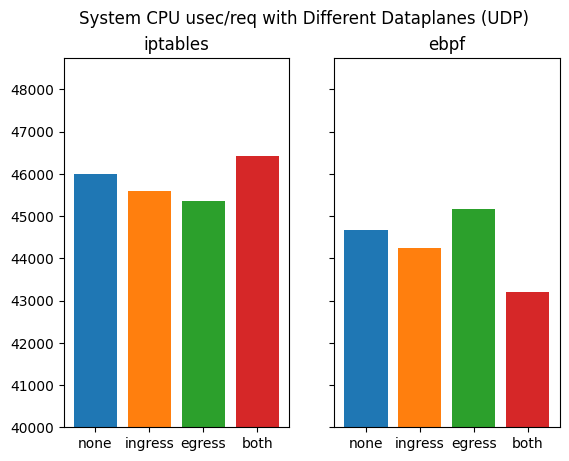

In [9]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('System CPU usec/req with Different Dataplanes (UDP)')

# UDP Iptables
experimentstocompare = [{'id': '40812'}, {'id': '40813'}, {'id': '40814'}, {'id': '40815'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=0, filter="UDP")

# UDP eBPF
experimentstocompare = [{'id': '40816'}, {'id': '40817'}, {'id': '40818'}, {'id': '40819'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=1, filter="UDP")

axs[0].set(ylim=40000)
plt.savefig('plots/cpu_usec_udp.pdf', format='pdf')

# HTTP

EXPID: 40780, RUNID: 1, DELTA=136546000
EXPID: 40780, RUNID: 2, DELTA=141136000
EXPID: 40780, RUNID: 3, DELTA=142049000
Mean: 139910333.33333334, Std: 2949143.3219383103
EXPID: 40781, RUNID: 1, DELTA=140446000
EXPID: 40781, RUNID: 2, DELTA=140310000
EXPID: 40781, RUNID: 3, DELTA=136662000
Mean: 139139333.33333334, Std: 2146510.9674383993
EXPID: 40782, RUNID: 1, DELTA=142009000
EXPID: 40782, RUNID: 2, DELTA=140376000
EXPID: 40782, RUNID: 3, DELTA=135698000
Mean: 139361000.0, Std: 3275644.8220159644
EXPID: 40783, RUNID: 1, DELTA=139296000
EXPID: 40783, RUNID: 2, DELTA=133603000
EXPID: 40783, RUNID: 3, DELTA=138827000
Mean: 137242000.0, Std: 3160178.9506292203
EXPID: 40767, RUNID: 1, DELTA=135340000
EXPID: 40767, RUNID: 2, DELTA=140734000
EXPID: 40767, RUNID: 3, DELTA=133532000
Mean: 136535333.33333334, Std: 3746840.9805239043
EXPID: 40768, RUNID: 1, DELTA=132743000
EXPID: 40768, RUNID: 2, DELTA=137244000
EXPID: 40768, RUNID: 3, DELTA=133129000
Mean: 134372000.0, Std: 2494701.785785227
EX

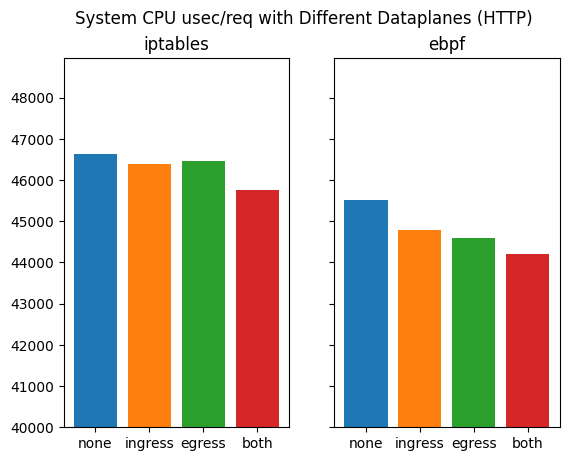

In [10]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('System CPU usec/req with Different Dataplanes (HTTP)')

# HTTP Iptables
experimentstocompare = [{'id': '40780'}, {'id': '40781'}, {'id': '40782'}, {'id': '40783'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=0, filter="HTTP")

# HTTP eBPF
experimentstocompare = [{'id': '40767'}, {'id': '40768'}, {'id': '40769'}, {'id': '40770'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=1, filter="HTTP")

axs[0].set(ylim=40000)
plt.savefig('plots/cpu_usec_http.pdf', format='pdf')

# TCP

EXPID: 40826, RUNID: 1, DELTA=134374000
EXPID: 40826, RUNID: 2, DELTA=135605000
EXPID: 40826, RUNID: 3, DELTA=137272000
Mean: 135750333.33333334, Std: 1454456.0266069693
EXPID: 40827, RUNID: 1, DELTA=139350000
EXPID: 40827, RUNID: 2, DELTA=136792000
EXPID: 40827, RUNID: 3, DELTA=133964000
Mean: 136702000.0, Std: 2694127.688139521
EXPID: 40828, RUNID: 1, DELTA=134110000
EXPID: 40828, RUNID: 2, DELTA=134086000
EXPID: 40828, RUNID: 3, DELTA=136032000
Mean: 134742666.66666666, Std: 1116659.9004770133
EXPID: 40829, RUNID: 1, DELTA=131549000
EXPID: 40829, RUNID: 2, DELTA=140781000
EXPID: 40829, RUNID: 3, DELTA=139486000
Mean: 137272000.0, Std: 4998380.037572173
EXPID: 40822, RUNID: 1, DELTA=131420000
EXPID: 40822, RUNID: 2, DELTA=136146000
EXPID: 40822, RUNID: 3, DELTA=130517000
Mean: 132694333.33333333, Std: 3023136.505904643
EXPID: 40823, RUNID: 1, DELTA=134069000
EXPID: 40823, RUNID: 2, DELTA=136129000
EXPID: 40823, RUNID: 3, DELTA=136281000
Mean: 135493000.0, Std: 1235559.7921590034
EXPI

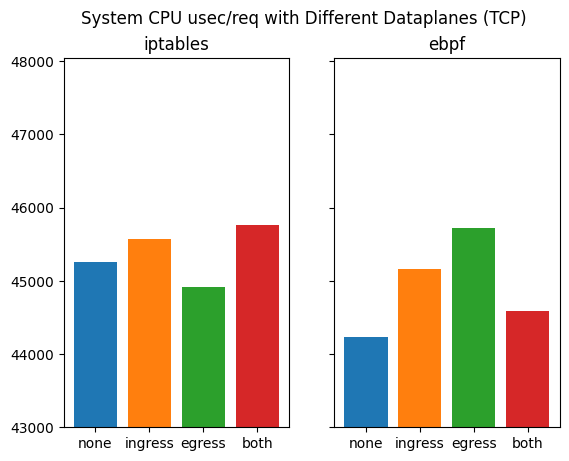

In [11]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('System CPU usec/req with Different Dataplanes (TCP)')

# TCP Iptables
experimentstocompare = [{'id': '40826'}, {'id': '40827'}, {'id': '40828'}, {'id': '40829'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=0, filter="TCP")

# TCP eBPF
experimentstocompare = [{'id': '40822'}, {'id': '40823'}, {'id': '40824'}, {'id': '40825'}]
plot_bar_cpu_per_req(experimentstocompare, axs, index=1, filter="TCP")

axs[0].set(ylim=43000)
plt.savefig('plots/cpu_usec_tcp.pdf', format='pdf')

# HTTP Istio

EXPID: 40780, RUNID: 1, DELTA=136546000
EXPID: 40780, RUNID: 2, DELTA=141136000
EXPID: 40780, RUNID: 3, DELTA=142049000
Mean: 139910333.33333334, Std: 2949143.3219383103
EXPID: 40785, RUNID: 1, DELTA=192739000
EXPID: 40785, RUNID: 2, DELTA=195960000
EXPID: 40785, RUNID: 3, DELTA=189857000
Mean: 192852000.0, Std: 3053068.7840269827
EXPID: 40784, RUNID: 1, DELTA=195185000
EXPID: 40784, RUNID: 2, DELTA=195033000
EXPID: 40784, RUNID: 3, DELTA=195599000
Mean: 195272333.33333334, Std: 292932.301621609
EXPID: 40787, RUNID: 1, DELTA=214594000
EXPID: 40787, RUNID: 2, DELTA=211680000
EXPID: 40787, RUNID: 3, DELTA=214205000
Mean: 213493000.0, Std: 1582105.2430227264
EXPID: 40786, RUNID: 1, DELTA=219050000
EXPID: 40786, RUNID: 2, DELTA=218328000
EXPID: 40786, RUNID: 3, DELTA=218849000
Mean: 218742333.33333334, Std: 372631.6322232096
EXPID: 40800, RUNID: 1, DELTA=130707000
EXPID: 40800, RUNID: 2, DELTA=134945000
EXPID: 40800, RUNID: 3, DELTA=134890000
Mean: 133514000.0, Std: 2431088.8507004427
EXPI

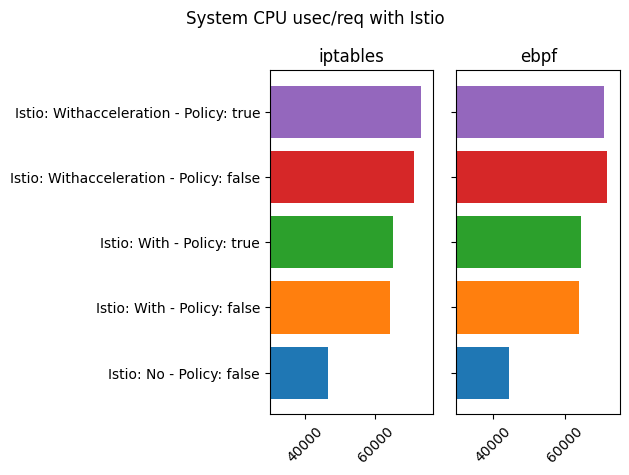

In [12]:
fig, axs = plt.subplots(1, 2,sharey=True)
fig.suptitle('System CPU usec/req with Istio')


# Iptables
experimentstocompare = [{'id': '40780', 'run': '1'}, {'id': '40785', 'run': '1'}, {'id': '40784', 'run': '1'}, {'id': '40787', 'run': '1'}, {'id': '40786', 'run': '1'}]
plot_bar_cpu_per_req_istio(experimentstocompare, axs, index=0)


# eBPF
experimentstocompare = [{'id': '40800', 'run': '1'}, {'id': '40773', 'run': '1'}, {'id': '40771', 'run': '1'}, {'id': '40775', 'run': '1'}, {'id': '40774', 'run': '1'}]
plot_bar_cpu_per_req_istio(experimentstocompare, axs, index=1)

#fig.legend(axs[0].get_legend_handles_labels()[0], axs[0].get_legend_handles_labels()[1], loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2)

plt.savefig('plots/cpu_usec_comparison_istio.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()
axs[0].set(xlim=30000)
axs[1].set(xlim=30000)
plt.show()

# Memory Istio

Plot how much memory Istio components use on average.

Mean mem_usage for EXPID: 40787, istio-proxy = 29.58652862409056 MB 	 Std: 0.42058537487067277
Mean mem_usage for EXPID: 40787, discovery = 39.06413905482027 MB 	 Std: 1.237232629860125
Mean mem_usage for EXPID: 40787, merbridge = 41.131438983381486 MB 	 Std: 0.05972395930567612


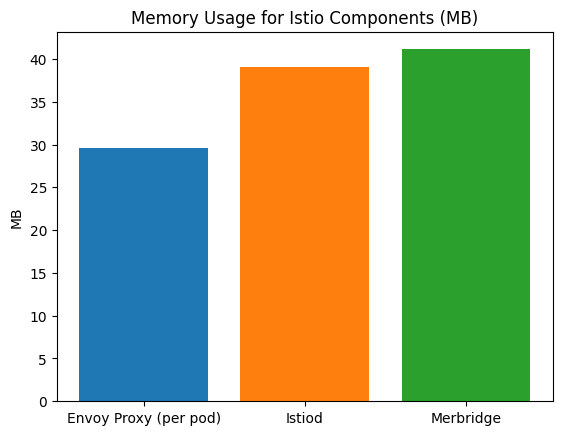

In [13]:
plt.title("Memory Usage for Istio Components (MB)")
plt.bar("Envoy Proxy (per pod)", get_mean_pod_memory_usage_expid("40787", "istio-proxy"))
plt.bar("Istiod", get_mean_pod_memory_usage_expid("40787", "discovery"))
plt.bar("Merbridge", get_mean_pod_memory_usage_expid("40787", "merbridge"))
plt.ylabel("MB")

plt.savefig('plots/istio_mem_usage.pdf', format='pdf', bbox_inches='tight')